In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset

df = pd.read_excel("Dataset.xlsx")

In [6]:
import os
os.listdir()

['Dataset .xlsx', 'images', 'Level1_Task1.ipynb']

In [ ]:
#display first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
#identify number of rows and columns

df.shape

(9551, 21)

In [13]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9551
Columns : 21


In [ ]:
#view columns
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [ ]:
#check data types
df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [ ]:
#check missing values
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [17]:
#handle missing values
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [18]:
#check again
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [19]:
#check duplicate rows
df.duplicated().sum()

0

In [20]:
#drop duplicate if exist
df = df.drop_duplicates()

In [ ]:
## Data Type Verification

The data types of all columns were checked using `df.dtypes` and `df.info()`.

After examining the dataset, it was observed that all columns have appropriate data types:

- Integer columns (`int64`) are used for numerical values such as Restaurant ID, Country Code, Average Cost for Two, Price Range, and Votes.
- Floating-point columns (`float64`) are used for Latitude, Longitude, and Aggregate Rating.
- Object (`object`) data type is used for text and categorical columns such as Restaurant Name, City, Cuisines, and Table Booking status.

Since all columns already have suitable data types, **no data type conversion was required**.

In [21]:
df["Aggregate rating"].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

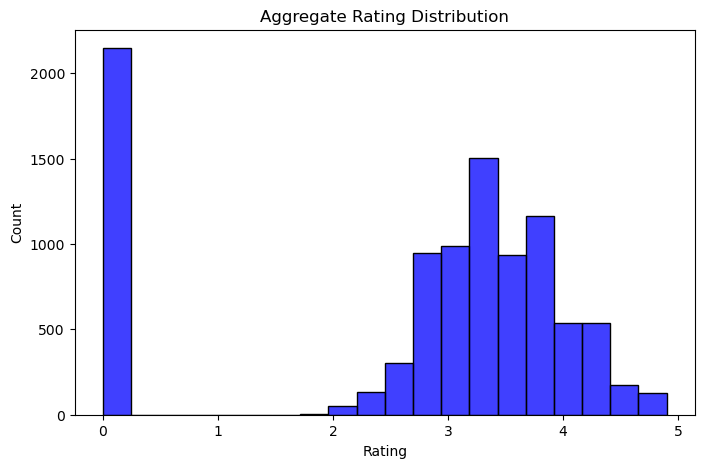

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["Aggregate rating"], bins=20, color="blue")
plt.title("Aggregate Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [24]:
#class imbalance
df["Aggregate rating"].value_counts()

Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
2.9     381
3.9     335
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     144
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      42
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64

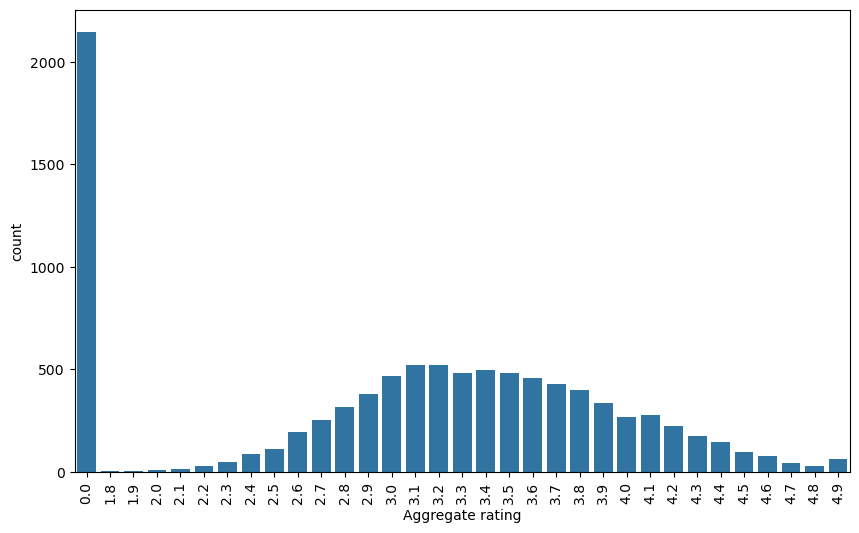

In [26]:
plt.figure(figsize=(10,6))
sns.countplot(x="Aggregate rating", data=df)
plt.xticks(rotation=90)
plt.show()

In [29]:
#save clean dataset
df.to_excel("Cleaned_Dataset.xlsx", index=False)

 #Observations

- The dataset contains **9551 rows** and **21 columns**.
- Missing values were found in the **Cuisines** column and were replaced with **"Unknown"**.
- Duplicate rows were checked and removed if any were found.
- The data types of all columns were verified, and necessary conversions were performed.
- The distribution of the **Aggregate Rating** shows that some rating values occur much more frequently than others, indicating a **class imbalance** in the target variable.

# Level 1 - Task 2
## Descriptive Analysis


In [30]:
#used cleaned_dataset
df = pd.read_excel("Cleaned_Dataset.xlsx")

In [31]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### Statistical Summary

- The dataset contains 9551 records for all numerical columns.
- The average aggregate rating is approximately **2.67**, while the median rating is **3.2**.
- Restaurant ratings range from **0.0** to **4.9**.
- The average cost for two people is **1199.21**, although the large standard deviation indicates considerable variation in restaurant pricing.

In [33]:
#calculate mean
df.mean(numeric_only=True)

Restaurant ID           9.051128e+06
Country Code            1.836562e+01
Longitude               6.412657e+01
Latitude                2.585438e+01
Average Cost for two    1.199211e+03
Price range             1.804837e+00
Aggregate rating        2.666370e+00
Votes                   1.569097e+02
dtype: float64

In [34]:
#calculate median
df.median(numeric_only=True)

Restaurant ID           6.004089e+06
Country Code            1.000000e+00
Longitude               7.719196e+01
Latitude                2.857047e+01
Average Cost for two    4.000000e+02
Price range             2.000000e+00
Aggregate rating        3.200000e+00
Votes                   3.100000e+01
dtype: float64

In [35]:
#calculate standard deviation
df.std(numeric_only=True)

Restaurant ID           8.791521e+06
Country Code            5.675055e+01
Longitude               4.146706e+01
Latitude                1.100794e+01
Average Cost for two    1.612118e+04
Price range             9.056088e-01
Aggregate rating        1.516378e+00
Votes                   4.301691e+02
dtype: float64

In [ ]:
#count restaurants in each country code
country_counts = df["Country Code"].value_counts()

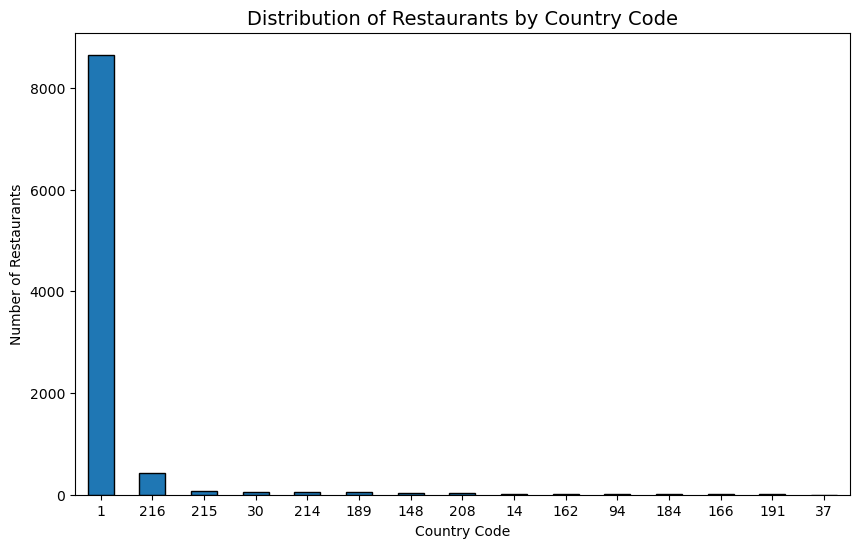

In [44]:
plt.figure(figsize=(10,6))

country_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Restaurants by Country Code", fontsize=14)
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.show()

In [39]:
#count resaurants by city
df["City"].value_counts()

City
New Delhi           5473
Gurgaon             1118
Noida               1080
Faridabad            251
Ghaziabad             25
                    ... 
Panchkula              1
Mc Millan              1
Mayfield               1
Macedon                1
Vineland Station       1
Name: count, Length: 141, dtype: int64

In [48]:
#top 5 cities
top_cities = df["City"].value_counts().head(5)
top_cities

City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

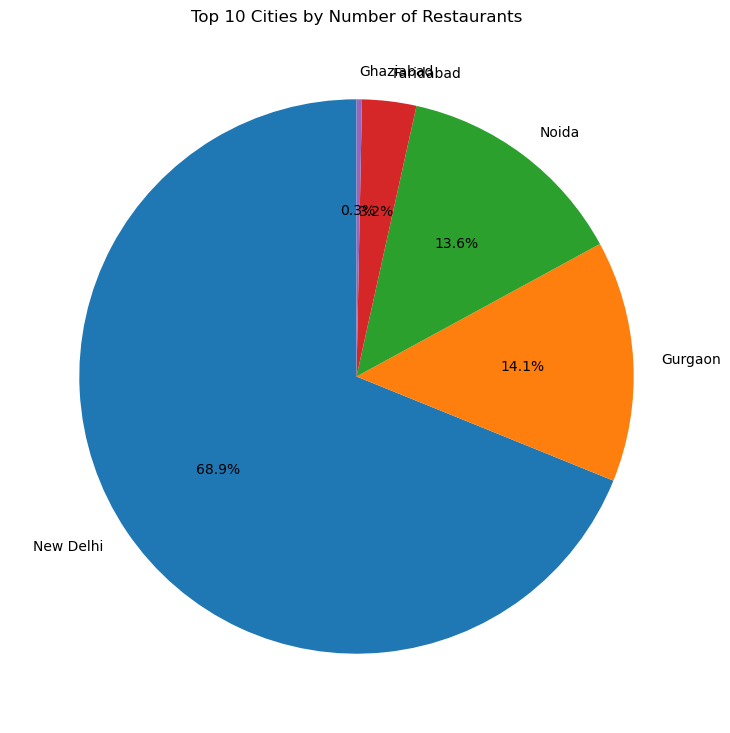

In [49]:
plt.figure(figsize=(9,9))

plt.pie(
    top_cities,
    labels=top_cities.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Cities by Number of Restaurants")

plt.show()

In [46]:
#top 10 cuisines
top_cuisines = df["Cuisines"].value_counts().head(10)

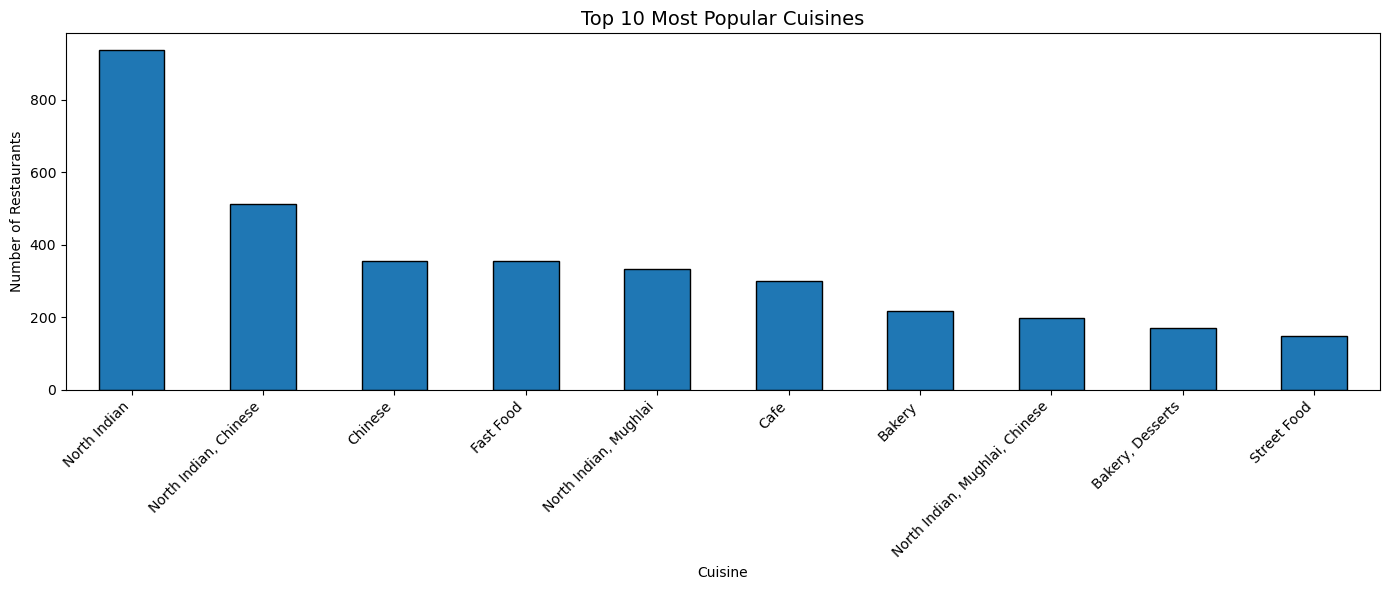

In [47]:
plt.figure(figsize=(14,6))

top_cuisines.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 10 Most Popular Cuisines", fontsize=14)
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

# Observations

- Basic statistical measures such as mean, median, standard deviation, minimum, and maximum were calculated for all numerical columns.
- The dataset contains restaurants from multiple countries, with **Country Code 1** having the highest number of restaurants.
- The city analysis shows that **New Delhi** has the highest number of restaurants, followed by **Gurgaon** and **Noida**.
- The cuisine analysis reveals that **North Indian** is the most common cuisine, followed by **North Indian, Chinese** and **Chinese**.
- The descriptive analysis provides useful insights into the distribution of restaurants across different countries, cities, and cuisines.


# Level 1 - Task 3
## Geospatial Analysis

In [57]:
import plotly.express as px

In [58]:
df[["Latitude","Longitude"]].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


In [59]:
fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    hover_name="Restaurant Name",
    hover_data={
        "City": True,
        "Aggregate rating": True,
        "Latitude": False,
        "Longitude": False
    },
    color="Aggregate rating",
    color_continuous_scale="Viridis",
    title="Restaurant Locations Around the World"
)

fig.show()

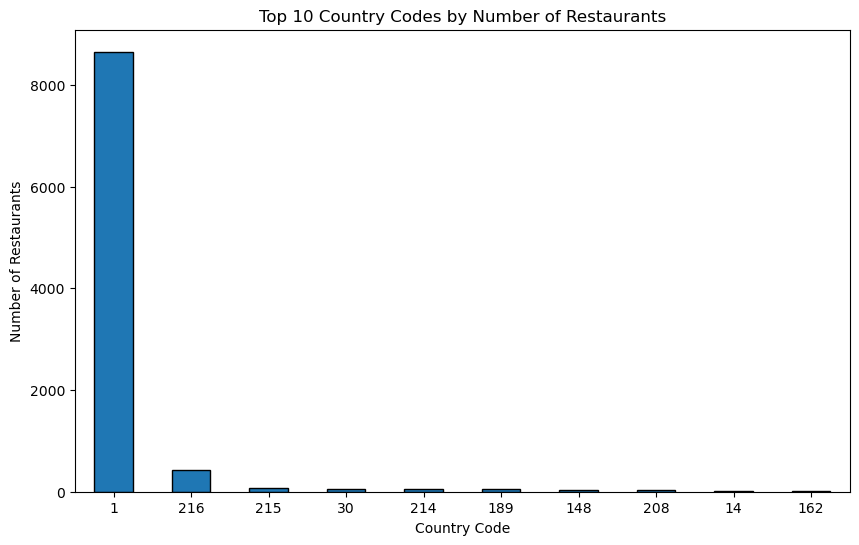

In [62]:
country_counts = df["Country Code"].value_counts().head(10)

plt.figure(figsize=(10,6))

country_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 10 Country Codes by Number of Restaurants")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.show()

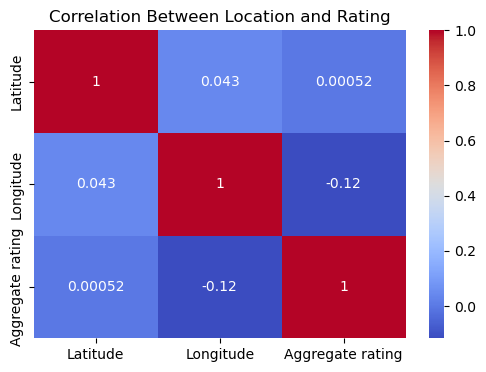

In [61]:
#Correlation Between Location and Rating
df[["Latitude", "Longitude", "Aggregate rating"]].corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df[["Latitude", "Longitude", "Aggregate rating"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Location and Rating")

plt.show()

# Observations

- Restaurant locations were successfully visualized using their latitude and longitude coordinates on an interactive world map.
- The restaurant distribution indicates that Country Code 1 contains the highest number of restaurants compared to other countries.
- The correlation analysis shows a very weak relationship between geographical location and aggregate rating.
- Latitude has almost no correlation with restaurant ratings, while longitude has a weak negative correlation.
- Overall, restaurant ratings do not appear to depend significantly on geographical location.